#Data Imports and Configuration

In [1]:
# imports
import pandas as pd
import requests
import zipfile
import io
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
# Dataset Config

DATA_URLS = {
    "stack_overflow": "https://survey.stackoverflow.co/datasets/stack-overflow-developer-survey-2023.zip",
    "levels_fyi": "https://raw.githubusercontent.com/Yashas-153/Data-Science-Stem-Salaries/main/Levels_Fyi_Salary_Data.csv",
    "glassdoor": "https://raw.githubusercontent.com/PlayingNumbers/ds_salary_proj/master/glassdoor_jobs.csv"
}

# settings
REQUEST_TIMEOUT = 60

In [3]:
#  TEMPORAL NORMALIZATION Configuration
REFERENCE_YEAR = 2023
MIN_YEAR = 2018  # filter outdated data

# EXTERNAL JUSTIFICATION: GLOBAL UPLIFT FACTOR (2021 -> 2023)
# Source: US Bureau of Labor Statistics (BLS) - Annual Average CPI-U
# 2021 Annual Avg CPI: 270.97
# 2023 Annual Avg CPI: 304.70
# Formula: CPI_2023 / CPI_2021 = Cumulative Inflation Multiplier
CPI_2021 = 270.97
CPI_2023 = 304.70
GLOBAL_UPLIFT_FACTOR = CPI_2023 / CPI_2021  # ≈ 1.124 (12.4% growth)

# Map regional CPI factors instead of a blanket global factor
REGIONAL_CPI_FACTORS = {
    "united states": CPI_2023 / CPI_2021,  # ~1.124
    "united kingdom": 1.142,
    "germany": 1.138,
    "india": 1.189,
    "canada": 1.131,
    "default": CPI_2023 / CPI_2021  # fallback
}

# Data Acquisition

In [4]:
# DATA LOADING FUNCTIONS
def load_stackoverflow_data(url: str):
    """Load Stack Overflow Survey dataset and schema directly from ZIP (in-memory)."""

    print(" Fetching Stack Overflow dataset...")
    response = requests.get(url, timeout=REQUEST_TIMEOUT)
    response.raise_for_status()

    print(" Extracting ZIP and loading CSVs...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Load main dataset
        with z.open('survey_results_public.csv') as f:
            df = pd.read_csv(f)

        # Load schema file
        with z.open('survey_results_schema.csv') as f_schema:
            df_schema = pd.read_csv(f_schema)

    print(f" Stack Overflow data loaded: {df.shape}")
    print(f" Stack Overflow schema loaded: {df_schema.shape}")
    return df, df_schema

def load_csv_data(url: str, name: str) -> pd.DataFrame:
    """Generic CSV loader from URL."""

    print(f" Fetching {name} dataset...")
    df = pd.read_csv(url)

    print(f" {name} loaded: {df.shape}")
    return df

# LOADING ALL DATASETS
df_stack, df_schema = load_stackoverflow_data(DATA_URLS["stack_overflow"])
df_levels = load_csv_data(DATA_URLS["levels_fyi"], "Levels.fyi")
df_glassdoor = load_csv_data(DATA_URLS["glassdoor"], "Glassdoor")

 Fetching Stack Overflow dataset...
 Extracting ZIP and loading CSVs...
 Stack Overflow data loaded: (89184, 84)
 Stack Overflow schema loaded: (78, 6)
 Fetching Levels.fyi dataset...
 Levels.fyi loaded: (62642, 29)
 Fetching Glassdoor dataset...
 Glassdoor loaded: (956, 15)


In [5]:
# BASIC INSPECTION UTILITIES
def inspect_dataset(df: pd.DataFrame, name: str):
    """Quick inspection of dataset."""

    print(f" DATASET: {name}")

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum().sort_values(ascending=False).head(10))

    print("\nSample Rows:")
    display(df.head())

# INSPECT ALL DATASETS
inspect_dataset(df_stack, "Stack Overflow Data")

print("\n" + "="*50)
print(" DATASET: Stack Overflow Schema")
print("="*50)
display(df_schema.head())

inspect_dataset(df_levels, "Levels.fyi")
inspect_dataset(df_glassdoor, "Glassdoor")

 DATASET: Stack Overflow Data
Shape: (89184, 84)

Columns:
['ResponseId', 'Q120', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'TechList', 'BuyNewTool', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackSyncHaveWorkedWith', 'OfficeStackSyncWantToWorkWith', 'AISearchHaveWorkedWith', 'AISearchWantToWorkWith', 'AIDevHaveWorkedWith', 'AIDevWantToWor

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0



 DATASET: Stack Overflow Schema


,qid,qname,question,force_resp,type,selector
0,QID16,S0,"<div><span style=""font-size:19px;""><strong>Hel...",False,DB,TB
1,QID12,MetaInfo,Browser Meta Info,False,Meta,Browser
2,QID310,Q310,"<div><span style=""font-size:19px;""><strong>You...",False,DB,TB
3,QID312,Q120,,True,MC,SAVR
4,QID1,S1,"<span style=""font-size:22px; font-family: aria...",False,DB,TB


 DATASET: Levels.fyi
Shape: (62642, 29)

Columns:
['timestamp', 'company', 'level', 'title', 'totalyearlycompensation', 'location', 'yearsofexperience', 'yearsatcompany', 'tag', 'basesalary', 'stockgrantvalue', 'bonus', 'gender', 'otherdetails', 'cityid', 'dmaid', 'rowNumber', 'Masters_Degree', 'Bachelors_Degree', 'Doctorate_Degree', 'Highschool', 'Some_College', 'Race_Asian', 'Race_White', 'Race_Two_Or_More', 'Race_Black', 'Race_Hispanic', 'Race', 'Education']

Missing Values:
Race                       40215
Education                  32272
otherdetails               22508
gender                     19540
tag                          870
level                        123
company                        5
dmaid                          2
location                       0
totalyearlycompensation        0
dtype: int64

Sample Rows:


,timestamp,company,level,title,totalyearlycompensation,location,yearsofexperience,yearsatcompany,tag,basesalary,...,Doctorate_Degree,Highschool,Some_College,Race_Asian,Race_White,Race_Two_Or_More,Race_Black,Race_Hispanic,Race,Education
0,6/7/2017 11:33:27,Oracle,L3,Product Manager,127000,"Redwood City, CA",1.5,1.5,NaN,107000.0,...,0,0,0,0,0,0,0,0,NaN,NaN
1,6/10/2017 17:11:29,eBay,SE 2,Software Engineer,100000,"San Francisco, CA",5.0,3.0,NaN,0.0,...,0,0,0,0,0,0,0,0,NaN,NaN
2,6/11/2017 14:53:57,Amazon,L7,Product Manager,310000,"Seattle, WA",8.0,0.0,NaN,155000.0,...,0,0,0,0,0,0,0,0,NaN,NaN
3,6/17/2017 0:23:14,Apple,M1,Software Engineering Manager,372000,"Sunnyvale, CA",7.0,5.0,NaN,157000.0,...,0,0,0,0,0,0,0,0,NaN,NaN
4,6/20/2017 10:58:51,Microsoft,60,Software Engineer,157000,"Mountain View, CA",5.0,3.0,NaN,0.0,...,0,0,0,0,0,0,0,0,NaN,NaN


 DATASET: Glassdoor
Shape: (956, 15)

Columns:
['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

Missing Values:
Unnamed: 0         0
Job Title          0
Salary Estimate    0
Job Description    0
Rating             0
Company Name       0
Location           0
Headquarters       0
Size               0
Founded            0
dtype: int64

Sample Rows:


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [6]:
# ADDING SOURCE IDENTIFIER (IMPORTANT FOR MERGING)
df_stack["data_source"] = "stack_overflow"
df_levels["data_source"] = "levels_fyi"
df_glassdoor["data_source"] = "glassdoor"


#QUICK TARGET CHECK (VERY IMPORTANT)
print("\n TARGET VARIABLE CHECK")

print("\nStack Overflow Salary Column:")
print("ConvertedCompYearly" in df_stack.columns)

print("\nLevels.fyi Salary Column:")
print("totalyearlycompensation" in df_levels.columns)

print("\nGlassdoor Salary Column:")
print("Salary Estimate" in df_glassdoor.columns)


 TARGET VARIABLE CHECK

Stack Overflow Salary Column:
True

Levels.fyi Salary Column:
True

Glassdoor Salary Column:
True


# Feature Selection and Column Pruning

In [7]:
# STACK OVERFLOW

STACK_KEEP = [
    "ConvertedCompYearly",
    "Age", "Employment", "RemoteWork", "EdLevel",
    "YearsCodePro", "DevType", "OrgSize",
    "Country", "Industry",
    "LanguageHaveWorkedWith",
    "DatabaseHaveWorkedWith",
    "PlatformHaveWorkedWith"
]

# Keep only existing columns (safe selection)
df_stack = df_stack.loc[:, df_stack.columns.intersection(STACK_KEEP)].copy()

print(f" Stack Overflow pruned: {df_stack.shape}")


 Stack Overflow pruned: (89184, 13)


In [8]:
# LEVELS.FYI

LEVELS_KEEP = [
    "totalyearlycompensation",
    "yearsofexperience",
    "title",
    "company",
    "location",
    "basesalary",
    "stockgrantvalue",
    "bonus",
    "timestamp"  # for temporal step
]

df_levels = df_levels.loc[:, df_levels.columns.intersection(LEVELS_KEEP)].copy()

print(f" Levels.fyi pruned: {df_levels.shape}")

 Levels.fyi pruned: (62642, 9)


In [9]:
# GLASSDOOR
GLASSDOOR_KEEP = [
    "Job Title",
    "Salary Estimate",
    "Job Description",
    "Rating",
    "Company Name",
    "Location",
    "Industry",
    "Sector",
    "Size"
]

df_glassdoor = df_glassdoor.loc[:, df_glassdoor.columns.intersection(GLASSDOOR_KEEP)].copy()

print(f" Glassdoor pruned: {df_glassdoor.shape}")

 Glassdoor pruned: (956, 9)


# Basic Cleaning

In [10]:
def standardize_columns(df):
    df.columns = df.columns.str.lower().str.strip()
    return df

In [11]:
def clean_text_series(s):
    return s.astype(str).str.strip().str.lower()

In [12]:
def cap_outliers(df, col, upper_q=0.99):
    if col in df.columns:
        upper = df[col].quantile(upper_q)
        return df[df[col] <= upper]
    return df

In [13]:
# Standardize Column Names
df_stack = standardize_columns(df_stack)
df_levels = standardize_columns(df_levels)
df_glassdoor = standardize_columns(df_glassdoor)

In [14]:
# Remove Missing Target
df_stack = df_stack[df_stack["convertedcompyearly"].notna()]
df_levels = df_levels[df_levels["totalyearlycompensation"].notna()]

In [15]:
# Remove Duplicates
df_stack = df_stack.drop_duplicates()
df_levels = df_levels.drop_duplicates()
df_glassdoor = df_glassdoor.drop_duplicates()

In [16]:
# Type Conversion
df_stack["yearscodepro"] = pd.to_numeric(df_stack.get("yearscodepro"), errors="coerce")
df_levels["yearsofexperience"] = pd.to_numeric(df_levels.get("yearsofexperience"), errors="coerce")

df_stack["convertedcompyearly"] = pd.to_numeric(df_stack.get("convertedcompyearly"), errors="coerce")
df_levels["totalyearlycompensation"] = pd.to_numeric(df_levels.get("totalyearlycompensation"), errors="coerce")


In [17]:
# Outlier Handling (Top 1%)
df_stack = cap_outliers(df_stack, "convertedcompyearly")
df_levels = cap_outliers(df_levels, "totalyearlycompensation")

In [18]:
# Clean Categorical Columns

cat_cols_stack = [
    "employment", "remotework", "edlevel",
    "devtype", "orgsize", "country", "industry"
]

for col in cat_cols_stack:
    if col in df_stack.columns:
        df_stack[col] = clean_text_series(df_stack[col])

In [19]:
# Handle Missing Non-Critical Fields
df_stack = df_stack.fillna({
    "industry": "unknown",
    "orgsize": "unknown"
})

df_levels = df_levels.fillna({
    "company": "unknown"
})


In [20]:
# Reset Index
for df in [df_stack, df_levels, df_glassdoor]:
    df.reset_index(drop=True, inplace=True)

In [21]:
# Final Check
print(" Cleaning Completed")
print(f"Stack Overflow: {df_stack.shape}")
print(f"Levels.fyi: {df_levels.shape}")
print(f"Glassdoor: {df_glassdoor.shape}")

 Cleaning Completed
Stack Overflow: (47563, 13)
Levels.fyi: (62041, 9)
Glassdoor: (600, 9)


# Temporal Normalisation

In [22]:
# EXTRACT TEMPORAL SIGNAL (LEVELS.FYI)
df_levels["timestamp"] = pd.to_datetime(df_levels["timestamp"], errors="coerce")
df_levels["year"] = df_levels["timestamp"].dt.year

In [23]:
# TEMPORAL FILTERING
df_levels = df_levels[df_levels["year"] >= MIN_YEAR].copy()
df_levels["original_salary"] = df_levels["totalyearlycompensation"]

In [24]:
# COMPUTE DATA-DRIVEN SCALING FACTORS
# Get the maximum year actually available in the dataset (likely 2021)
MAX_LEVELS_YEAR = df_levels["year"].max()
yearly_medians = df_levels.groupby("year")["original_salary"].median()

# Anchor the initial normalization to this max year
target_median = yearly_medians.get(MAX_LEVELS_YEAR)

# Create dynamic map: scale = target_median(2021) / year_median
dynamic_scale_map = (target_median / yearly_medians).to_dict()

print(f"\nData-Driven Multipliers (Anchored to {MAX_LEVELS_YEAR}):")
for yr, mult in dynamic_scale_map.items():
    print(f"  {yr}: {mult:.4f}x multiplier")


Data-Driven Multipliers (Anchored to 2021):
  2018: 0.8381x multiplier
  2019: 0.8800x multiplier
  2020: 0.9412x multiplier
  2021: 1.0000x multiplier


In [25]:
# APPLYING NORMALIZATION & UPLIFT (Vectorized)
print("\nApplying regional economic uplift to reach 2023 baseline...")

# Assign the correct regional factor based on the location column
df_levels["cpi_factor"] = df_levels["location"].map(
    lambda loc: next(
        (v for k, v in REGIONAL_CPI_FACTORS.items() if k in str(loc).lower()),
        REGIONAL_CPI_FACTORS["default"]
    )
)

# We use .map() instead of .apply() for significantly faster performance
df_levels["normalized_salary"] = (
    df_levels["original_salary"]
    * df_levels["year"].map(dynamic_scale_map).fillna(1.0)
    * df_levels["cpi_factor"]
)


Applying regional economic uplift to reach 2023 baseline...


In [26]:
# STACK OVERFLOW ALIGNMENT
df_stack["year"] = REFERENCE_YEAR

# Safely handle the column name (accounting for capitalization differences)
target_col = 'ConvertedCompYearly' if 'ConvertedCompYearly' in df_stack.columns else 'convertedcompyearly'
df_stack["normalized_salary"] = df_stack[target_col]
df_stack["original_salary"] = df_stack[target_col]

In [27]:
# RIGOROUS VALIDATION CHECKS
def validate_temporal_alignment():
    print(" TEMPORAL NORMALIZATION VALIDATION")

    print("\n LEVELS.FYI (Market Calibration)")
    print(f"Year range: {df_levels['year'].min()} → {df_levels['year'].max()}")

    # Group by year to show the statistical "flattening" effect
    validation_df = df_levels.groupby("year").agg(
        Count=("original_salary", "count"),
        Original_Median=("original_salary", "median"),
        Normalized_Median=("normalized_salary", "median")
    ).reset_index()

    print(f"\nBefore vs. After Normalization (Target Baseline: {REFERENCE_YEAR}):")
    display(validation_df)

    print("\n STACK OVERFLOW (Merit Baseline)")
    print(f"Assigned Year: {df_stack['year'].iloc[0]} (Static Snapshot)")
    print("Salary stats (Normalized):")
    print(df_stack["normalized_salary"].describe()[["mean", "50%", "std"]].to_frame().T)

validate_temporal_alignment()

 TEMPORAL NORMALIZATION VALIDATION

 LEVELS.FYI (Market Calibration)
Year range: 2018 → 2021

Before vs. After Normalization (Target Baseline: 2023):


,year,Count,Original_Median,Normalized_Median
0,2018,3840,210000.0,197908.255526
1,2019,11050,200000.0,197908.255526
2,2020,23750,187000.0,197908.255526
3,2021,23218,176000.0,197908.255526



 STACK OVERFLOW (Merit Baseline)
Assigned Year: 2023 (Static Snapshot)
Salary stats (Normalized):
                           mean      50%           std
normalized_salary  89043.291382  74963.0  65945.091769


# SALARY NORMALIZATION

In [28]:
# STACK OVERFLOW VALIDATION

# Remove unrealistic salaries
df_stack = df_stack[
    (df_stack["normalized_salary"] > 1_000) &
    (df_stack["normalized_salary"] < 1_000_000)
].copy()

# Ensure numeric
df_stack["normalized_salary"] = pd.to_numeric(df_stack["normalized_salary"], errors="coerce")

In [29]:
# LEVELS.FYI FINALIZATION

# Remove invalid values
df_levels = df_levels[
    (df_levels["normalized_salary"].notna()) &
    (df_levels["normalized_salary"] > 1_000)
].copy()

df_levels["normalized_salary"] = pd.to_numeric(df_levels["normalized_salary"], errors="coerce")

In [30]:
# GLASSDOOR SALARY PARSING

def parse_salary(text):
    if pd.isna(text):
        return np.nan

    text = text.lower()

    # Extract numbers like 53K, 91K
    matches = re.findall(r'(\d+\.?\d*)\s*k', text)

    if len(matches) == 0:
        return np.nan

    values = [float(x) * 1000 for x in matches]

    # If range → take mean
    if len(values) >= 2:
        return np.mean(values[:2])

    return values[0]

df_glassdoor["salary"] = df_glassdoor["salary estimate"].apply(parse_salary)

# Drop invalid rows
df_glassdoor = df_glassdoor[df_glassdoor["salary"].notna()].copy()

# Remove unrealistic values
df_glassdoor = df_glassdoor[
    (df_glassdoor["salary"] > 1_000) &
    (df_glassdoor["salary"] < 1_000_000)
]

In [31]:
# GLASSDOOR TEMPORAL ADJUSTMENT (Conservative Estimate)
# Glassdoor dataset is known to be ~2019-2020 vintage.
# Applying the inflation multiplier AFTER the salary is successfully parsed!
df_glassdoor["original_salary"] = df_glassdoor["salary"].copy()  # Save pre-uplift salary cleanly
df_glassdoor["salary"] = df_glassdoor["original_salary"] * 1.08  # ~4yr inflation estimate

In [32]:
# UNIFIED SALARY COLUMN
df_stack["salary"] = df_stack["normalized_salary"]
df_levels["salary"] = df_levels["normalized_salary"]

# Already created for Glassdoor
# df_glassdoor["salary"]

# Add source metadata
df_stack["salary_source"] = "stack"
df_levels["salary_source"] = "levels"
df_glassdoor["salary_source"] = "glassdoor"


In [33]:
# GLOBAL OUTLIER HANDLING

combined_salary = pd.concat([
    df_stack["salary"],
    df_levels["salary"],
    df_glassdoor["salary"]
])

lower = combined_salary.quantile(0.01)
upper = combined_salary.quantile(0.99)

def clip(df):
    return df[(df["salary"] >= lower) & (df["salary"] <= upper)]

df_stack = clip(df_stack)
df_levels = clip(df_levels)
df_glassdoor = clip(df_glassdoor)


In [34]:
# LOG TRANSFORMATION
for df in [df_stack, df_levels, df_glassdoor]:
    df["log_salary"] = np.log1p(df["salary"])


In [35]:
#  VALIDATION
def salary_validation():
    print("\n" + "="*50)
    print(" SALARY NORMALIZATION VALIDATION")
    print("="*50)

    for name, df in {
        "Stack Overflow": df_stack,
        "Levels.fyi": df_levels,
        "Glassdoor": df_glassdoor
    }.items():

        print(f"\n{name}")
        print("-"*40)

        stats = df["salary"].describe()[["mean", "50%", "std"]]
        print("Raw Salary Stats:")
        print(stats.to_frame().T)

        log_stats = df["log_salary"].describe()[["mean", "50%", "std"]]
        print("\nLog Salary Stats:")
        print(log_stats.to_frame().T)

salary_validation()


 SALARY NORMALIZATION VALIDATION

Stack Overflow
----------------------------------------
Raw Salary Stats:
                mean      50%           std
salary  92439.149338  77010.5  64883.618349

Log Salary Stats:
                 mean       50%       std
log_salary  11.164447  11.25171  0.808709

Levels.fyi
----------------------------------------
Raw Salary Stats:
                 mean            50%            std
salary  214989.267794  195791.589692  107217.347196

Log Salary Stats:
                 mean        50%       std
log_salary  12.139706  12.184811  0.568192

Glassdoor
----------------------------------------
Raw Salary Stats:
                 mean       50%          std
salary  110851.247265  106380.0  38837.65909

Log Salary Stats:
                 mean        50%       std
log_salary  11.554107  11.574782  0.359834


In [36]:
# FINAL STRUCTURE CHECK
REQUIRED_COLS = ["salary", "log_salary", "original_salary", "year"]

def check_structure(df, name):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    print(f"\n{name} missing columns:", missing if missing else "None")

check_structure(df_stack, "Stack")
check_structure(df_levels, "Levels")
check_structure(df_glassdoor, "Glassdoor")


Stack missing columns: None

Levels missing columns: None

Glassdoor missing columns: ['year']


In [37]:
#  FINAL SUMMARY
print("\n SALARY NORMALIZATION COMPLETE")
print(f"Stack Overflow: {df_stack.shape}")
print(f"Levels.fyi: {df_levels.shape}")
print(f"Glassdoor: {df_glassdoor.shape}")


 SALARY NORMALIZATION COMPLETE
Stack Overflow: (45782, 19)
Levels.fyi: (60766, 16)
Glassdoor: (457, 13)


# SCHEMA ALIGNMENT

In [38]:
# DEFINE TARGET SCHEMA
TARGET_COLUMNS = [
    "salary", "log_salary", "original_salary", "year",
    "experience", "education", "role", "company",
    "location", "industry", "skills_structured", "skills_text", "data_source"
]

In [39]:
def safe_get_col(df, col):
    return df[col].astype(str) if col in df.columns else pd.Series("", index=df.index)

# STACK OVERFLOW TRANSFORM
df_stack_aligned = pd.DataFrame({
    "salary": df_stack["salary"],
    "log_salary": df_stack["log_salary"],
    "original_salary": df_stack["original_salary"],
    "year": df_stack["year"],

    "experience": df_stack.get("yearscodepro"),
    "education": df_stack.get("edlevel"),
    "role": df_stack.get("devtype"),
    "company": np.nan,

    "location": df_stack.get("country"),
    "industry": df_stack.get("industry"),

    # Robust skills concatenation
    "skills_structured": (
        safe_get_col(df_stack, "languagehaveworkedwith") + ";" +
        safe_get_col(df_stack, "databasehaveworkedwith") + ";" +
        safe_get_col(df_stack, "platformhaveworkedwith")
    ),
    "skills_text": np.nan,

    "data_source": "stack_overflow"
})

In [40]:
# LEVELS.FYI TRANSFORM
df_levels_aligned = pd.DataFrame({
    "salary": df_levels["salary"],
    "log_salary": df_levels["log_salary"],
    "original_salary": df_levels["original_salary"],
    "year": df_levels["year"],

    "experience": df_levels.get("yearsofexperience"),
    "education": np.nan,  # sparse → drop

    "role": df_levels.get("title"),
    "company": df_levels.get("company"),

    "location": df_levels.get("location"),
    "industry": np.nan,  # not available

    "skills_structured": np.nan,
    "skills_text": np.nan,

    "data_source": "levels_fyi"
})

In [41]:
# GLASSDOOR TRANSFORM
df_glassdoor["year"] = np.nan  # Genuinely unknown snapshot

df_glassdoor_aligned = pd.DataFrame({
    "salary": df_glassdoor["salary"],
    "log_salary": df_glassdoor["log_salary"],
    "original_salary": df_glassdoor["original_salary"], # Uses the cleanly saved copy
    "year": df_glassdoor["year"],

    "experience": np.nan,
    "education": np.nan,

    "role": df_glassdoor.get("job title"),
    "company": df_glassdoor.get("company name"),

    "location": df_glassdoor.get("location"),
    "industry": df_glassdoor.get("industry"),

    # NLP text block for Glassdoor
    "skills_structured": np.nan,
    "skills_text": df_glassdoor.get("job description"),

    "data_source": "glassdoor"
})

In [42]:
# COMBINE DATASETS
df_final = pd.concat(
    [df_stack_aligned, df_levels_aligned, df_glassdoor_aligned],
    ignore_index=True
)
# Ensure column order
df_final = df_final[TARGET_COLUMNS]

In [43]:
# Killing 'Year' as a feature to prevent structural leakage
df_final["year_audit"] = df_final["year"]
df_final["year_imputed"] = df_final["year_audit"].isna() # Flag the Glassdoor rows
df_final = df_final.drop(columns=["year"])

In [44]:
# Addressing Dataset Imbalance (Inverse-Frequency Source Weights)
source_counts = df_final["data_source"].value_counts()
total = len(df_final)
df_final["sample_weight"] = df_final["data_source"].map(
    lambda s: total / (len(source_counts) * source_counts[s])
)

In [45]:
# Domain Adaptation (Z-score normalize within each source)
# Reserved for domain-adaptive modeling in Phase 2
# Train models on salary_within_source_zscore, reconstruct using per-source mean/std
df_final["salary_within_source_zscore"] = df_final.groupby("data_source")["salary"].transform(
    lambda x: (x - x.mean()) / x.std()
)

In [46]:
# FINAL CLEANUP
# Standardize text columns
text_cols = ["education", "role", "company", "location", "industry", "skills_structured", "skills_text"]

for col in text_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str).str.strip().str.lower()

# Replace "nan" strings created by pandas text manipulation with actual NaN
df_final[text_cols] = df_final[text_cols].replace('nan', np.nan)

In [47]:
# Store audit info separately, completely outside df_final to prevent accidental leakage
audit_df = df_final[["year_audit", "year_imputed", "data_source"]].copy()
df_final = df_final.drop(columns=["year_audit", "year_imputed"])

In [48]:
# VALIDATION
print(" FINAL DATASET VALIDATION")

print("\nShape:", df_final.shape)

print("\nData Source Distribution:")
print(df_final["data_source"].value_counts())

print("\nMissing Values (Top 10):")
print(df_final.isnull().sum().sort_values(ascending=False).head(10))

print("\nSalary Stats:")
print(df_final["salary"].describe()[["mean", "50%", "std"]].to_frame().T)

print("\nLog Salary Stats:")
print(df_final["log_salary"].describe()[["mean", "50%", "std"]].to_frame().T)

 FINAL DATASET VALIDATION

Shape: (107005, 14)

Data Source Distribution:
data_source
levels_fyi        60766
stack_overflow    45782
glassdoor           457
Name: count, dtype: int64

Missing Values (Top 10):
skills_text          106548
industry              80067
education             61223
skills_structured     61223
company               45782
experience             1736
role                     93
original_salary           0
salary                    0
log_salary                0
dtype: int64

Salary Stats:
                 mean       50%            std
salary  162111.546206  143637.0  109597.517355

Log Salary Stats:
                 mean        50%       std
log_salary  11.719941  11.875052  0.834209


# EDA Visualization

In [49]:
def safe_series(df, col):
    return df[col].dropna() if col in df.columns else None

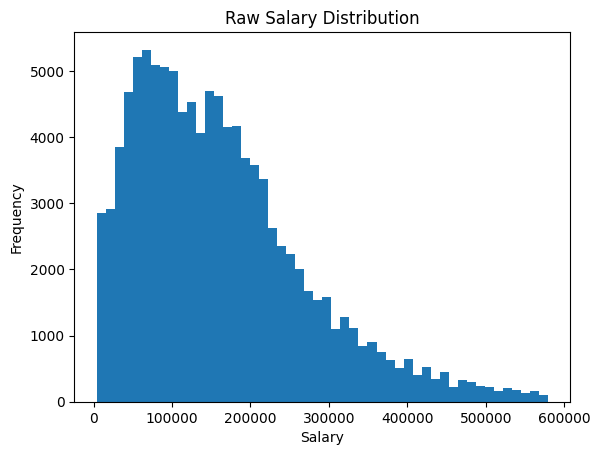

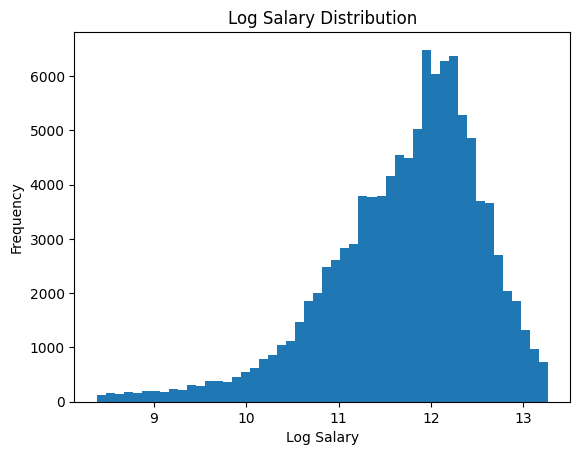

In [50]:
# GLOBAL SALARY DISTRIBUTION
plt.figure()
plt.hist(safe_series(df_final, "salary"), bins=50)
plt.title("Raw Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(safe_series(df_final, "log_salary"), bins=50)
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.show()


**Salary Distribution (Raw vs Log)**

**Raw Salary**
* Right-skewed with long tail up to ~$600K$
* Peak around $60K$–$100K$ (realistic global distribution)
* Hidden bimodality → mixed populations (Levels.fyi vs Stack Overflow)

**Log Salary**
* Near-normal distribution (center ~log(12) ≈ $160K$)
* Reduced variance and outlier impact
* Reveals low-salary subpopulation (<$15K$)

**Conclusion:**
Log transformation is necessary and correct, but dataset contains multi-population structure.

<Figure size 640x480 with 0 Axes>

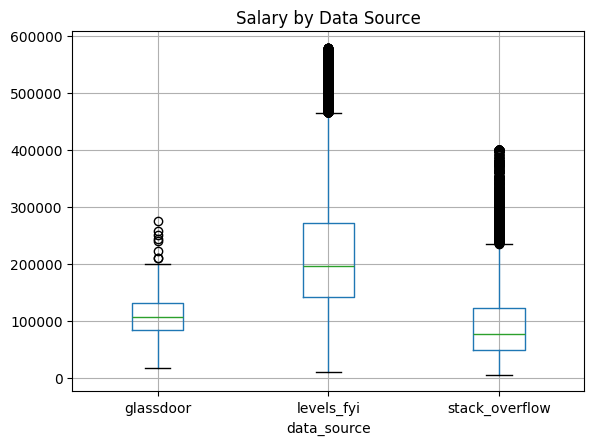

In [51]:
# DATASET-WISE COMPARISON
plt.figure()
df_final.boxplot(column="salary", by="data_source")
plt.title("Salary by Data Source")
plt.suptitle("")
plt.show()

**Dataset-wise Salary Comparison**
* Levels.fyi ≫ Stack Overflow ≈ Glassdoor

* **Clear hierarchy:** Levels.fyi (~200K) > Glassdoor (~100K) > Stack (~85K)

* Extreme outliers still present in Levels.fyi
* Stack Overflow contains very low salaries (global noise)

**Conclusion:**
Dataset is diverse but highly heterogeneous → requires domain adaptation / weighting

<Figure size 640x480 with 0 Axes>

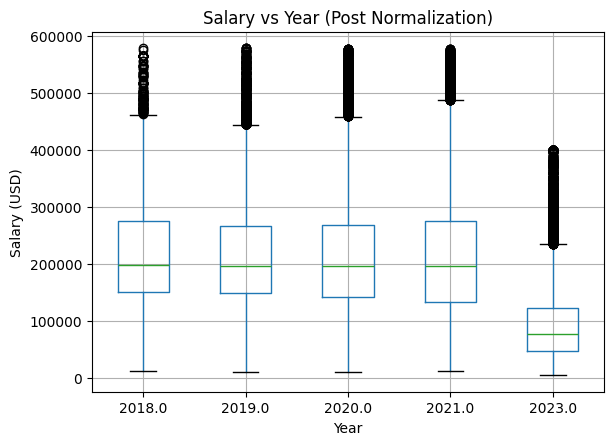

In [52]:
# TEMPORAL NORMALIZATION CHECK
if "year_audit" in audit_df.columns:
    plt.figure()
    # Combine audit column with salary just for this plot, dropping NaNs
    plot_data = pd.DataFrame({
        'year_audit': audit_df['year_audit'],
        'salary': df_final['salary']
    }).dropna(subset=['year_audit'])

    plot_data.boxplot(column="salary", by="year_audit")
    plt.title("Salary vs Year (Post Normalization)")
    plt.suptitle("")
    plt.xlabel("Year")
    plt.ylabel("Salary (USD)")
    plt.show()

# Temporal Normalization
* 2018–2021 medians aligned (~$190K$–$210K$) →  success
* 2023 drop (~$85$K) is dataset composition artifact, not temporal issue

**Conclusion:**
Temporal normalization is correct, but year must not be used as predictive feature

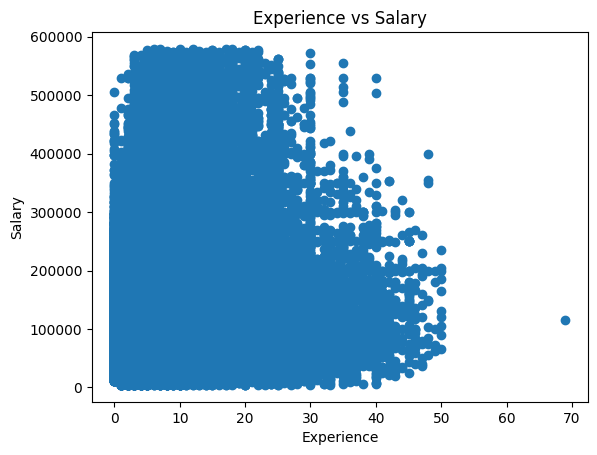

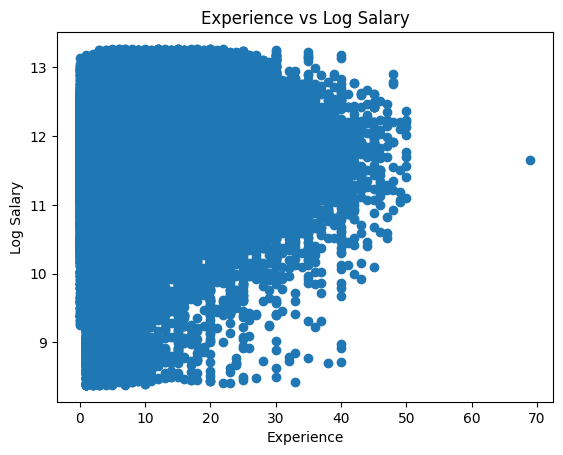

In [53]:
# EXPERIENCE vs SALARY
if "experience" in df_final.columns:
    plt.figure()
    plt.scatter(df_final["experience"], df_final["salary"])
    plt.title("Experience vs Salary")
    plt.xlabel("Experience")
    plt.ylabel("Salary")
    plt.show()

    plt.figure()
    plt.scatter(df_final["experience"], df_final["log_salary"])
    plt.title("Experience vs Log Salary")
    plt.xlabel("Experience")
    plt.ylabel("Log Salary")
    plt.show()

**Experience vs Salary (Raw vs Log)**

**Raw**
* Weak positive trend up to ~25 years
* Plateau/decline after 25–30 years (artifact)
* Vertical stripes → low granularity (integer values)

**Log**
* Clearer upward trend (0–25 years)
* High noise beyond 30 years
* Relationship still weak globally

**Conclusion:**
Experience is not a strong standalone predictor → requires interaction (role, location)

<Figure size 640x480 with 0 Axes>

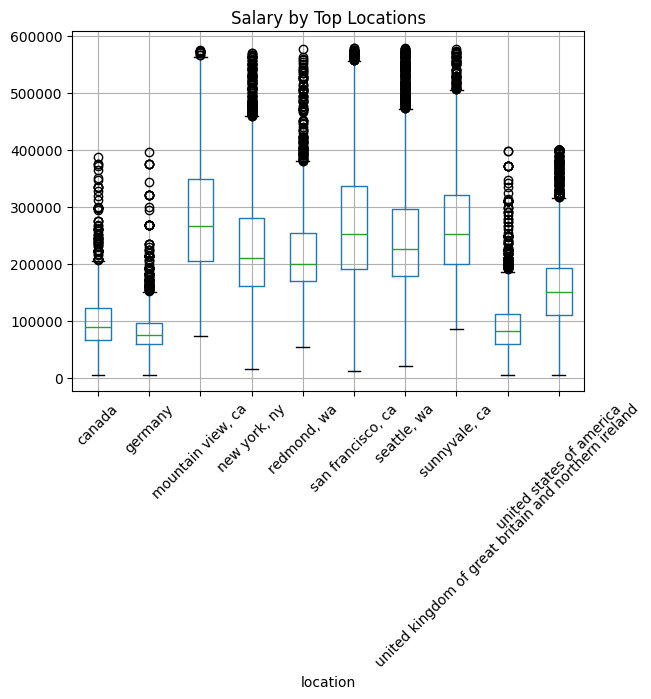

In [54]:
# LOCATION vs SALARY
if "location" in df_final.columns:
    top_locations = df_final["location"].value_counts().head(10).index
    df_loc = df_final[df_final["location"].isin(top_locations)]

    plt.figure()
    df_loc.boxplot(column="salary", by="location", rot=45)
    plt.title("Salary by Top Locations")
    plt.suptitle("")
    plt.show()

**Location vs Salary**

* Strong geographic disparity:
   * US tech hubs (~$230K–$280K)
   * Canada/Germany (~$80K–$100K)
* Wide spread even within same location
* Low salaries in high-paying regions → data contamination

**Conclusion:**
Location is the strongest driver of salary (bias source)

<Figure size 640x480 with 0 Axes>

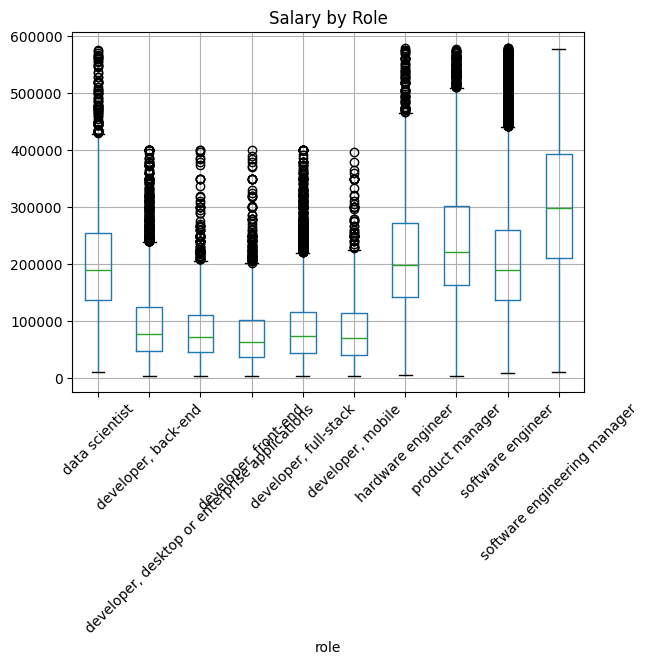

In [55]:
# ROLE vs SALARY
if "role" in df_final.columns:
    top_roles = df_final["role"].value_counts().head(10).index
    df_role = df_final[df_final["role"].isin(top_roles)]

    plt.figure()
    df_role.boxplot(column="salary", by="role", rot=45)
    plt.title("Salary by Role")
    plt.suptitle("")
    plt.show()

**Role vs Salary**

* **Clear hierarchy:**

    Manager > Engineer > Developer
* Developer roles nearly identical → redundant categories
* High variance within roles (cross-source mixing)

**Conclusion:**
Role is a strong merit signal, but needs category consolidation

<Figure size 640x480 with 0 Axes>

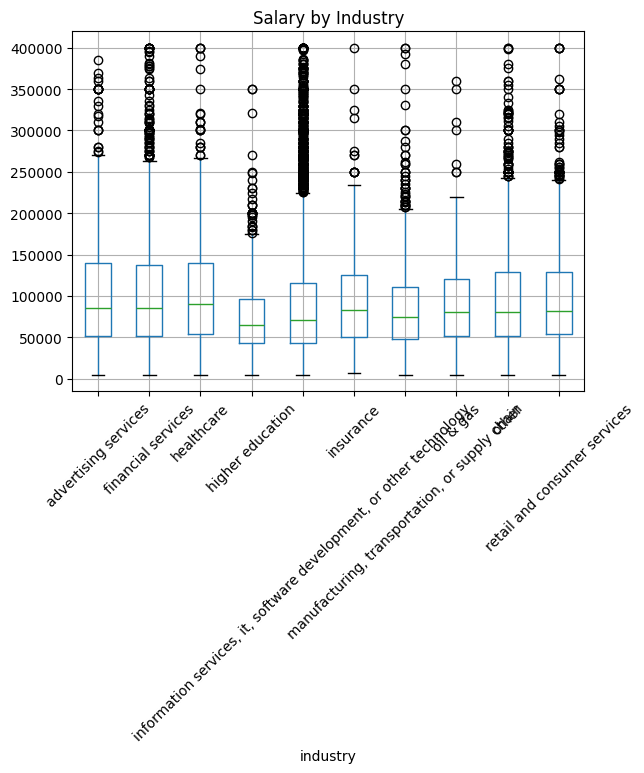

In [56]:
# INDUSTRY vs SALARY
if "industry" in df_final.columns:
    top_ind = df_final["industry"].value_counts().head(10).index
    df_ind = df_final[df_final["industry"].isin(top_ind)]

    plt.figure()
    df_ind.boxplot(column="salary", by="industry", rot=45)
    plt.title("Salary by Industry")
    plt.suptitle("")
    plt.show()

**Industry vs Salary**
* Slight variation (Finance > Education, etc.)
* Heavy overlap across industries
* Missing high-salary data (Levels.fyi lacks industry)

**Conclusion:**
Industry is a weak predictor → secondary feature only

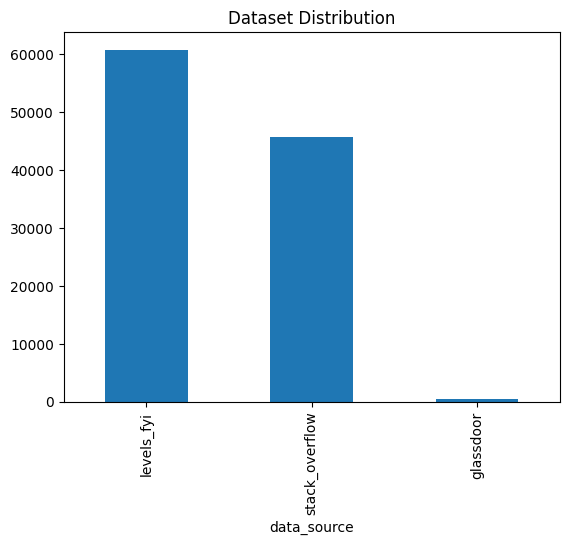

In [57]:
# DATASET BALANCE
plt.figure()
df_final["data_source"].value_counts().plot(kind="bar")
plt.title("Dataset Distribution")
plt.show()

**Dataset Distribution**
* ~107K rows → strong scale
* Levels.fyi ($60K$) > Stack ($45K$) >>> Glassdoor (~$457$)

**Conclusion:**
Severe imbalance → model will bias toward Levels.fyi unless weighted

<Figure size 640x480 with 0 Axes>

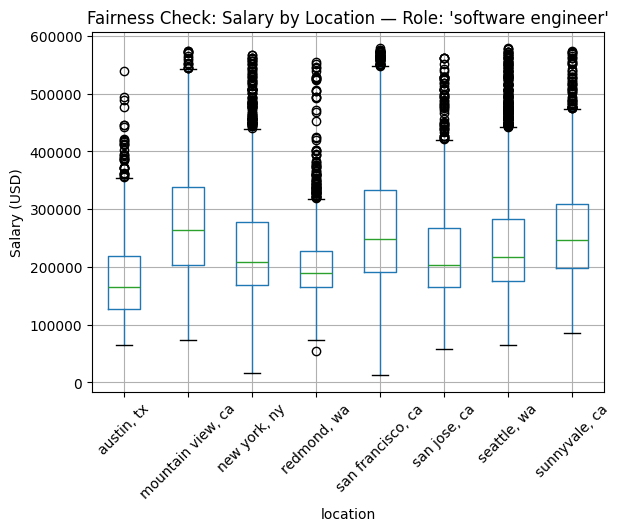

In [58]:
# FAIRNESS PRE-CHECK
if "role" in df_final.columns and "location" in df_final.columns:
    # Pick ONE specific role for a clean, controlled fairness plot
    focal_role = df_final["role"].value_counts().index[0]
    df_fair = df_final[df_final["role"] == focal_role]

    top_locs = df_fair["location"].value_counts().head(8).index
    df_fair = df_fair[df_fair["location"].isin(top_locs)]

    plt.figure()
    df_fair.boxplot(column="salary", by="location", rot=45)
    plt.title(f"Fairness Check: Salary by Location — Role: '{focal_role}'")
    plt.suptitle("")
    plt.ylabel("Salary (USD)")
    plt.show()

**Fairness Check (Same Role, Different Locations)**

* Same role → huge salary differences:

* ~$260K$ vs ~$165K$ (within US)
Merit held constant → disparity persists

**Conclusion:**
Confirms systemic location-based inequality → core justification of project

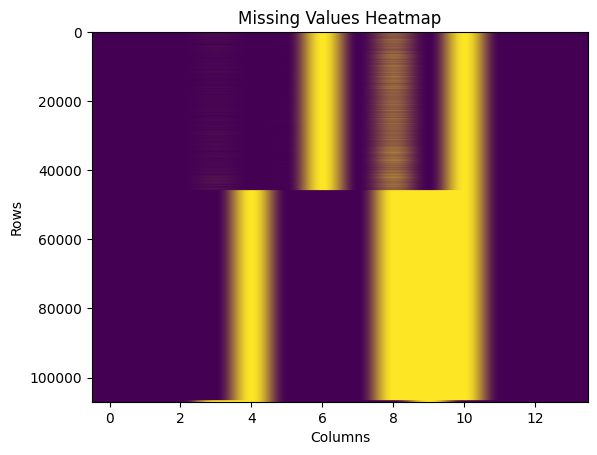

In [59]:
# MISSING VALUES
plt.figure()
plt.imshow(df_final.isnull(), aspect='auto')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

**Missing Values**
* Core target (salary) → complete
* Other features → 40–60% missing across datasets
* Feature coverage is non-overlapping across sources:
  * Levels → experience/company
  * Stack → skills/education
  * Glassdoor → industry/text

**Conclusion:**
Dataset is structurally sparse → requires:

* feature-specific modeling OR
* careful imputation strategy